# Shape & skew on a different dataset: world life expectancy

*Part 1 · Lesson 2 · another dataset  ·  data: Gapminder life expectancy, 2007*

*↩ A companion to [Lesson 2: Distributions: shape, skew & outliers](02-distributions-shape-outliers.ipynb).*

**↩ Back:** [Lesson 2: Distributions: shape, skew & outliers](02-distributions-shape-outliers.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](02-distributions-shape-outliers~the-code.ipynb)

In the core lesson the tails pointed **right**: Old Faithful had two crowds, and Lending Club's incomes trailed off into a long *high* tail that dragged the mean **above** the median. Now we point the same tools at a different world: the **life expectancy** of 142 countries in 2007.

The shape here is the mirror image. Most countries cluster at long, comfortable lifespans, but a cluster of countries with much shorter lifespans forms a long tail on the **low** side. That makes the distribution **left-skewed** — and flips the mean-vs-median story upside down. Same histogram, same skew number, same IQR rule, opposite-pointing tale.

Run each grey cell with **Shift + Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

# Gapminder: one row per country per year. We take the 2007 cross-section.
gap = sl.load_csv('gapminder.csv',
                  url='https://raw.githubusercontent.com/kirenz/datasets/master/gapminder.csv')
g07 = gap[gap['year'] == 2007].copy()        # 142 countries, one snapshot

print(f"Gapminder 2007: {len(g07)} countries, columns {list(g07.columns)}")
print(f"Continents: {sorted(g07['continent'].unique())}")
g07[['country', 'continent', 'lifeExp', 'gdpPercap']].head()

Gapminder 2007: 142 countries, columns ['country', 'continent', 'year', 'lifeExp', 'pop', 'gdpPercap']
Continents: ['Africa', 'Americas', 'Asia', 'Europe', 'Oceania']


,country,continent,lifeExp,gdpPercap
11,Afghanistan,Asia,43.828,974.580338
23,Albania,Europe,76.423,5937.029526
35,Algeria,Africa,72.301,6223.367465
47,Angola,Africa,42.731,4797.231267
59,Argentina,Americas,75.320,12779.379640


## 1) A frequency table — counting by bins

Just as in the core lesson, the simplest way to *see* a distribution is to chop the number line into equal slices ("bins") and count how many values land in each. That count is a **frequency table**, and it is exactly what a histogram draws.

- **The math:** pick bin edges, then for each bin count $f_k =$ (number of values $x$ with edge$_k \le x <$ edge$_{k+1}$).
- **The meaning:** each $f_k$ is a tally — how *crowded* that slice of the number line is.
- **The interpretation:** the *pattern* of the tallies is the shape of the data. One hump, two humps, a long tail — the table hints at it before we draw anything.

Let's tally the 142 life expectancies (in years), in 5-year bins.

In [2]:
le = g07['lifeExp']                              # life expectancy, years
edges = np.arange(35, 85 + 5, 5)                 # bin edges every 5 years
table = pd.cut(le, bins=edges, right=False).value_counts().sort_index()
freq = table.rename('count').to_frame()
freq['bar'] = freq['count'].apply(lambda c: '#' * c)   # a tiny text histogram
print(freq.to_string())
print(f"\nTotal countries: {freq['count'].sum()}")

          count                                      bar
lifeExp                                                 
[35, 40)      1                                        #
[40, 45)      8                                 ########
[45, 50)     10                               ##########
[50, 55)     12                             ############
[55, 60)     12                             ############
[60, 65)      9                                #########
[65, 70)      7                                  #######
[70, 75)     39  #######################################
[75, 80)     31          ###############################
[80, 85)     13                            #############

Total countries: 142


Read the `bar` column from the bottom up. The crowd lives **high** — the 70–80 year bins are packed. Then, trailing off below, a thin but real string of countries runs all the way down into the 40s and high 30s. The bulk is on the right; the **straggle is on the left**.

That low straggle is the headline. Where the core lesson's tail of high incomes reached to the *right*, this tail of short lifespans reaches to the *left*. Keep that direction in mind — we're about to drop the summary numbers onto it.

## 2) The histogram — and where the "average" lands

A **histogram** is the frequency table drawn as bars. Let's draw it with finer bins and mark the **mean** and **median**.

- **Mean** $\displaystyle \bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ — the balance point.
- **Median** — the middle value when sorted.

For a tidy symmetric distribution these sit on top of each other. Watch them *separate* here — and notice which one ends up on the left.

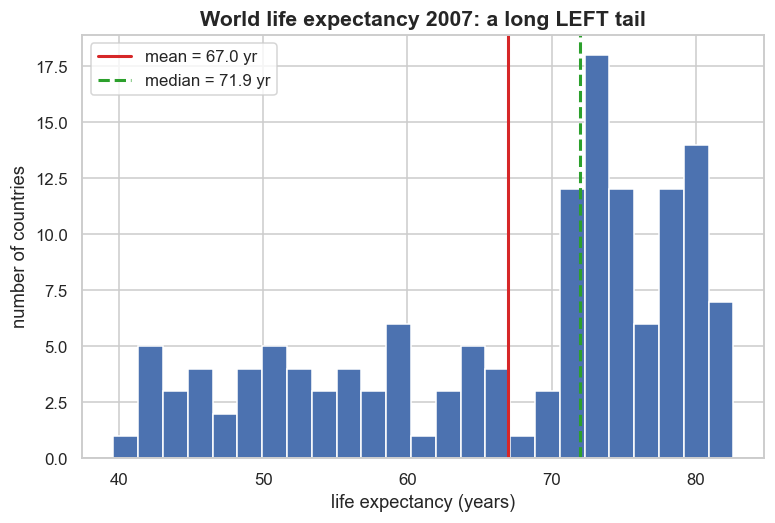

mean   = 67.01 yr
median = 71.94 yr
The mean sits 4.9 years BELOW the median -> pulled down by the low tail.


In [3]:
bins = 25                       # try 15-30; tinker with this
mean_le, median_le = le.mean(), le.median()

fig, ax = plt.subplots()
ax.hist(le, bins=bins, color='#4c72b0', edgecolor='white')
ax.axvline(mean_le,   color='#d62728', lw=2,          label=f'mean = {mean_le:.1f} yr')
ax.axvline(median_le, color='#2ca02c', lw=2, ls='--', label=f'median = {median_le:.1f} yr')
ax.set_xlabel('life expectancy (years)'); ax.set_ylabel('number of countries')
ax.set_title('World life expectancy 2007: a long LEFT tail')
ax.legend(); plt.show()

print(f"mean   = {mean_le:.2f} yr")
print(f"median = {median_le:.2f} yr")
print(f"The mean sits {median_le - mean_le:.1f} years BELOW the median -> pulled down by the low tail.")

**The hook:** the **mean (red, ~67 yr)** lands clearly to the **left** of the **median (green, ~72 yr)**. In the core lesson income's high tail dragged the mean *up*, above the median; here the low tail of short-lifespan countries drags the mean *down*, below it. The balance point gets pulled toward the long tail — and this time the long tail is on the low side.

- **The meaning:** the median (about 72) says "the middle country lives into its early 70s," which matches the packed right-hand crowd. The mean (about 67) is lower because the arithmetic average has to make room for the countries down in the 40s and 50s.
- **The interpretation:** when mean and median disagree, the *direction* of the gap tells you which way the tail points. Mean **below** median means the tail trails off to the **left**.

## 3) Skew has a sign — and here it is negative

**Skewness** puts a number on lopsidedness. Zero means symmetric. A **positive** value means a longer **right** tail (the income case from the core lesson); a **negative** value means a longer **left** tail (our case).

- **The math:** skewness is the average cubed z-score, $\text{skew} = \frac{1}{n}\sum\left(\frac{x_i - \bar{x}}{s}\right)^3$. Cubing keeps the sign, so values far out on one side dominate and decide which way it tips.
- **The meaning:** the long tail of low values **drags the mean toward it** (downward), while the median (just the middle country) barely moves.
- **The interpretation — the rule of thumb, now flipped:**
  $$\text{mean} < \text{median} \;\Rightarrow\; \text{left-skewed (long left tail)}.$$

In [4]:
sk = le.skew()
print(f"n        = {len(le)}")
print(f"mean     = {mean_le:.2f} yr")
print(f"median   = {median_le:.2f} yr")
print(f"std      = {le.std(ddof=1):.2f} yr")
print(f"min      = {le.min():.2f} yr   max = {le.max():.2f} yr")
print(f"skewness = {sk:.2f}   (0 = symmetric; NEGATIVE = long LEFT tail)")
print()
print("mean < median  ->  " + ("LEFT-skewed" if mean_le < median_le else "not left-skewed"))
print(f"\nCompare to the core lesson: Lending Club income had skew = +9.0 (long RIGHT tail,")
print(f"mean > median). Here the sign is NEGATIVE, so everything points the other way.")

n        = 142
mean     = 67.01 yr
median   = 71.94 yr
std      = 12.07 yr
min      = 39.61 yr   max = 82.60 yr
skewness = -0.69   (0 = symmetric; NEGATIVE = long LEFT tail)

mean < median  ->  LEFT-skewed

Compare to the core lesson: Lending Club income had skew = +9.0 (long RIGHT tail,
mean > median). Here the sign is NEGATIVE, so everything points the other way.


The skewness is about **−0.69** — the minus sign is the whole point. It says the same thing the histogram and the mean-below-median gap already told us: the tail points **left**. The core lesson's income skew was a large *positive* number; flipping the sign flips the direction of the tail and flips which of mean/median gets pulled.

### A same-dataset right-skew counterpoint

To prove the sign really is about direction and not about this dataset, look at a *different* column of the very same 142 countries: **GDP per person**. Wealth is famously top-heavy — a few rich countries far out front — so we expect a long **right** tail and a **positive** skew, just like income in the core lesson.

Same 142 countries, different variable:
  lifeExp  skew = -0.69   (LEFT-skewed:  mean < median)
  gdpPercap skew = +1.22   (RIGHT-skewed: mean > median)


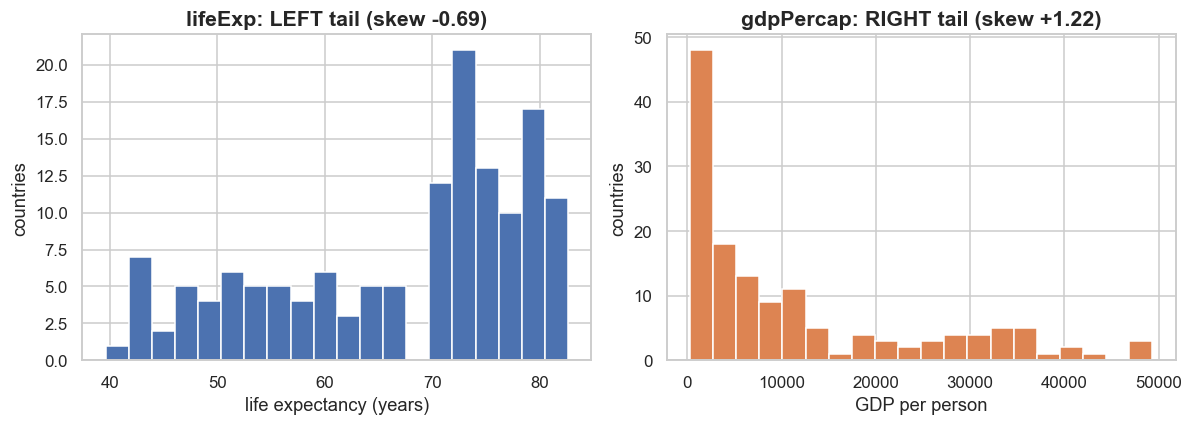

In [5]:
gdp = g07['gdpPercap']          # GDP per person (international dollars)
print("Same 142 countries, different variable:")
print(f"  lifeExp  skew = {le.skew():+.2f}   (LEFT-skewed:  mean {'<' if le.mean()  < le.median()  else '>'} median)")
print(f"  gdpPercap skew = {gdp.skew():+.2f}   (RIGHT-skewed: mean {'>' if gdp.mean() > gdp.median() else '<'} median)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(le, bins=20, color='#4c72b0', edgecolor='white')
axes[0].set_title(f'lifeExp: LEFT tail (skew {le.skew():+.2f})')
axes[0].set_xlabel('life expectancy (years)'); axes[0].set_ylabel('countries')
axes[1].hist(gdp, bins=20, color='#dd8452', edgecolor='white')
axes[1].set_title(f'gdpPercap: RIGHT tail (skew {gdp.skew():+.2f})')
axes[1].set_xlabel('GDP per person'); axes[1].set_ylabel('countries')
plt.tight_layout(); plt.show()

Two columns, one dataset, opposite tails. Life expectancy leans **left** (a few short-lived countries), GDP leans **right** (a few very rich ones). Same skewness tool; the **sign** alone tells you which way the long tail runs and therefore whether the mean is pulled below or above the median.

## 4) Outliers and the 1.5 × IQR rule

How far is "too far" out in a tail? The same automatic flag from the core lesson uses the **IQR** (interquartile range, the width of the middle 50%).

- **The math:** with quartiles $Q_1$ (25th pct) and $Q_3$ (75th pct), let $\text{IQR} = Q_3 - Q_1$. A value is flagged as an outlier if it falls below the **lower fence** $Q_1 - 1.5 \times \text{IQR}$ or above the **upper fence** $Q_3 + 1.5 \times \text{IQR}$.
- **The meaning:** the fences sit one-and-a-half box-widths beyond the box. The boxplot below draws exactly this: the box is $Q_1$–$Q_3$, the whiskers reach toward the fences, and anything past them is plotted as an individual dot.
- **The interpretation:** for skewed money data the core lesson flagged ~508 high earners. Here the story is different — let's see where (and whether) the rule fires.

Q1 = 57.2 yr   Q3 = 76.4 yr   IQR = 19.3 yr
Lower fence Q1 - 1.5*IQR = 28.3 yr
Upper fence Q3 + 1.5*IQR = 105.3 yr
Countries below the lower fence: 0
Countries above the upper fence: 0


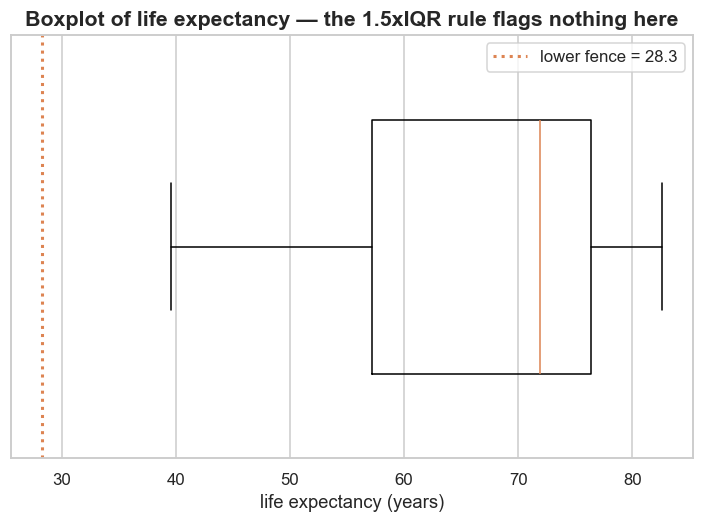

In [6]:
q1, q3 = le.quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
n_low  = (le < lower_fence).sum()
n_high = (le > upper_fence).sum()

print(f"Q1 = {q1:.1f} yr   Q3 = {q3:.1f} yr   IQR = {iqr:.1f} yr")
print(f"Lower fence Q1 - 1.5*IQR = {lower_fence:.1f} yr")
print(f"Upper fence Q3 + 1.5*IQR = {upper_fence:.1f} yr")
print(f"Countries below the lower fence: {n_low}")
print(f"Countries above the upper fence: {n_high}")

fig, ax = plt.subplots()
ax.boxplot(le, vert=False, widths=0.6, showfliers=True)
ax.axvline(lower_fence, color='#dd8452', lw=2, ls=':', label=f'lower fence = {lower_fence:.1f}')
ax.set_xlabel('life expectancy (years)')
ax.set_yticks([])
ax.set_title('Boxplot of life expectancy — the 1.5xIQR rule flags nothing here')
ax.legend(); plt.show()

The rule flags **zero** outliers — not one country on either side. That surprises people, because the histogram clearly *has* a low tail. What gives?

The IQR rule scales its fences to the spread of the data. Life expectancy is wide-spread but not *extreme*: the lowest value (about 39 years, Swaziland) is still well above the lower fence (about 28 years). The low tail is **long enough to skew the distribution** but **not so long that any single country sits past the fence**.

That's the real lesson: **skew and outliers are different questions.** A distribution can be clearly skewed (here, skew −0.69) yet have no 1.5×IQR outliers at all. Compare the core lesson, where strong right skew *did* push hundreds of incomes past the fence. The rule is a "look here" flag for *individual* extreme points — it is not a skew detector.

## 5) Robust vs non-robust — who survives the low tail

A statistic is **robust** if a few extreme values barely move it, and **non-robust** if they yank it around. The core lesson removed the single richest borrower; here we'll lop off the low end instead and watch what happens.

Predict first: if we drop the **10 countries with the lowest life expectancy**, which moves more — the mean or the median?

In [7]:
lowest10 = le.nsmallest(10)
without_low = le.drop(lowest10.index)

mean_full,   mean_drop   = le.mean(),   without_low.mean()
median_full, median_drop = le.median(), without_low.median()

print("Dropping the 10 lowest-lifeExp countries:")
print("  " + ", ".join(f"{c} ({v:.0f})" for c, v in
                        zip(g07.loc[lowest10.index, 'country'], lowest10)))
print()
print(f"{'':10}{'with':>12}{'without':>12}{'change':>12}")
print(f"{'mean':10}{mean_full:>12.2f}{mean_drop:>12.2f}{mean_drop-mean_full:>+12.2f}")
print(f"{'median':10}{median_full:>12.2f}{median_drop:>12.2f}{median_drop-median_full:>+12.2f}")

Dropping the 10 lowest-lifeExp countries:
  Swaziland (40), Mozambique (42), Zambia (42), Sierra Leone (43), Lesotho (43), Angola (43), Zimbabwe (43), Afghanistan (44), Central African Republic (45), Liberia (46)

                  with     without      change
mean             67.01       68.83       +1.82
median           71.94       72.44       +0.50


Dropping the 10 shortest-lived countries pulls the **mean up by several years** but nudges the **median only slightly**. That's the same robustness story as the core lesson, just acting on the *low* tail instead of the high one:

- **Robust** (resists extremes): **median**, **IQR**. They ask "who's in the middle / how wide is the middle?" — the tail doesn't get a vote.
- **Non-robust** (sensitive to extremes): **mean**, **standard deviation**, **range**. They use every value, so a tail full of low numbers drags them down.

**Interpretation:** for skewed data — in either direction — the **median** is usually the steadier "typical" value, and the gap between mean and median is itself a reading of the tail. Mean below median (as here) is the left-skew signature.

## 6) z-scores — a ruler that points both ways

A **z-score** rescales a value into "how many standard deviations from the mean":

$$z = \frac{x - \bar{x}}{s}.$$

This is *just arithmetic* — subtract the mean, divide by the SD — and it works on any numbers. The new wrinkle versus the core lesson: because this tail is on the **low** side, the most extreme z-scores are **negative**.

In [8]:
z = (le - le.mean()) / le.std(ddof=1)
i_min, i_max = z.idxmin(), z.idxmax()

print(f"Lowest  lifeExp: {g07.loc[i_min, 'country']:<15} {le[i_min]:.1f} yr  ->  z = {z.min():+.2f}")
print(f"Highest lifeExp: {g07.loc[i_max, 'country']:<15} {le[i_max]:.1f} yr  ->  z = {z.max():+.2f}")
print()
print(f"Most extreme |z| is on the LOW side ({z.min():.2f}), matching the left tail.")
print(f"Share of countries with z < -2: {(z < -2).mean()*100:.1f}%   (z > +2: {(z > 2).mean()*100:.1f}%)")

Lowest  lifeExp: Swaziland       39.6 yr  ->  z = -2.27
Highest lifeExp: Japan           82.6 yr  ->  z = +1.29

Most extreme |z| is on the LOW side (-2.27), matching the left tail.
Share of countries with z < -2: 4.2%   (z > +2: 0.0%)


The standout z-scores are **negative** — the farthest-from-typical country is one of the *short*-lived ones, sitting roughly 2.3 SDs **below** the mean. In the core lesson the headline z was a huge *positive* number (a high earner); here the ruler points the other way, exactly as the negative skew promised.

- **The meaning:** the z-score honestly reports distance from the mean in SD units, in whichever direction the value lies.
- **The interpretation — the same caveat as the core lesson:** a z-score is a **ruler, not a probability**. Turning a z into "the odds of being this far out" only works when the data is roughly **normal** (the bell curve). This distribution is skewed, so $z$ here is a *distance*, not a $p$-value. We earn the right to convert z-scores into probabilities in **Lesson 9 (the normal distribution)**.

### A hint of sub-clusters

One last echo of the core lesson's Old Faithful: the single hump here is really several overlapping crowds. Group the countries by **continent** and the left tail mostly resolves into one cluster — a reminder that "one distribution" can hide structure, just as Old Faithful's two peaks did.

C:\Users\jdj32\AppData\Local\Temp\ipykernel_25964\3809830035.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, vert=False, labels=order, widths=0.6)


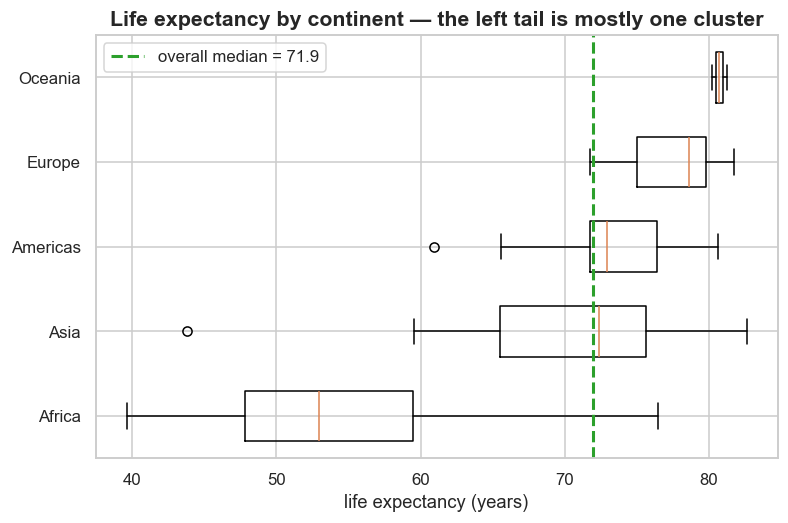

           count  median
continent               
Africa        52    52.9
Americas      25    72.9
Asia          33    72.4
Europe        30    78.6
Oceania        2    80.7


In [9]:
order = g07.groupby('continent')['lifeExp'].median().sort_values().index
data  = [g07.loc[g07['continent'] == c, 'lifeExp'].values for c in order]

fig, ax = plt.subplots()
ax.boxplot(data, vert=False, labels=order, widths=0.6)
ax.axvline(le.median(), color='#2ca02c', lw=2, ls='--', label=f'overall median = {le.median():.1f}')
ax.set_xlabel('life expectancy (years)'); ax.set_title('Life expectancy by continent — the left tail is mostly one cluster')
ax.legend(); plt.show()

print(g07.groupby('continent')['lifeExp'].agg(['count', 'median']).round(1).to_string())

The continents stack into clearly different bands: one sits well below the rest and accounts for most of the low tail, while the others bunch up high. The overall left skew is largely the gap between that one low cluster and the high-lifespan majority — multimodal structure hiding inside a single histogram, the same idea Old Faithful made obvious.

## Now you try

Predict the result, change one thing, then re-run:

1. **Bins change the story.** In the Section 2 histogram, set `bins = 8`, then `bins = 40`. Does the low tail still look like a tail with very few bins? Predict first, then check against the frequency table in Section 1.
2. **Flip the variable.** In Section 3's counterpoint cell, you saw `gdpPercap` is right-skewed. In a new cell, compute its mean and median and confirm `mean > median` (the opposite of `lifeExp`). Which "typical country" would you report for wealth, and why?
3. **Loosen the outlier fence.** In Section 4, change the `1.5` multiplier to `1.0` in both fences and re-run. Does the gentler fence now flag any low-tail countries? Predict whether it fires on the low side or the high side first.
4. **Robustness, dialed up.** In Section 5, drop the **30** lowest countries instead of 10 (`lowest = le.nsmallest(30)`) and recompute. How much does the mean move now versus the median?

## What you learned

- A **frequency table / histogram** reveals shape; world life expectancy in 2007 is **left-skewed** — a packed crowd of long-lived countries with a long tail trailing off to the **low** side. **Always plot.**
- **Skew has a sign.** A **negative** skewness (here about **−0.69**) means a long **left** tail and pulls the **mean below the median** (~67 vs ~72 yr) — the mirror image of the core lesson's right-skewed income, where mean was pulled *above* median. The same dataset's `gdpPercap` (skew ~**+1.2**) shows the right-skewed case for contrast.
- The **1.5 × IQR rule** flags points past the fences as outliers, but **skew and outliers are different questions**: this clearly skewed distribution had **zero** 1.5×IQR outliers, because the low tail is long enough to skew yet not long enough to push any country past a fence.
- **Robust** statistics (median, IQR) shrug off the tail; **non-robust** ones (mean, SD, range) get dragged — dropping the lowest countries moved the mean far more than the median.
- A **z-score** is "how many SDs from the mean" and points whichever way the value lies; here the most extreme z is **negative** (a low-lifespan country). On **non-normal** data a big z is a *distance*, not a probability (that comes in Lesson 9).
- Splitting by **continent** reveals sub-clusters inside the single hump — multimodal structure hiding in one distribution, echoing Old Faithful's two peaks.

---

**↩ Back to the lesson:** [Lesson 2: Distributions: shape, skew & outliers](02-distributions-shape-outliers.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](02-distributions-shape-outliers~the-code.ipynb)